#### Import required Python packages

In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import pandas as pd

#### Import sample data

In [3]:
my_df = pd.read_csv("data/sample_data_regression.csv")
print(my_df)

    output  input1  input2  input3
0      564     534     536     466
1      182     264     103     244
2      323     272     339     609
3      438     416     444     330
4      547     520     464     104
..     ...     ...     ...     ...
95     150     259     181     336
96     372     299     271     338
97     414     523     455     526
98     729     683     641     601
99     903     840     858     276

[100 rows x 4 columns]


#### Split data into input and output objects

In [4]:
X = my_df.drop(["output"], axis = 1)
y = my_df["output"]

#### Split data into training and test sets

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#### Instantiate our model object

In [8]:
regressor = RandomForestRegressor(random_state = 42, n_estimators = 1000)

#### Train our model

In [9]:
regressor.fit(X_train, y_train)

,n_estimators,1000
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Assess model accuracy

In [10]:
y_pred = regressor.predict(X_test)
r2_score(y_test, y_pred) 

0.6869519329653004

#### Feature importance

In [11]:
regressor.feature_importances_

array([0.40377534, 0.53531939, 0.06090527])

In [17]:
feature_importance = pd.DataFrame(regressor.feature_importances_)
feature_names = pd.DataFrame(X.columns)
feature_importance_summary = pd.concat([feature_names,feature_importance], axis = 1)
feature_importance_summary.columns = ["input_variable","feature_importance"]
feature_importance_summary.sort_values(by = "feature_importance", inplace = True)
print(feature_importance_summary)

  input_variable  feature_importance
2         input3            0.060905
0         input1            0.403775
1         input2            0.535319


#### Plot our model

In [18]:
import matplotlib.pyplot as plt

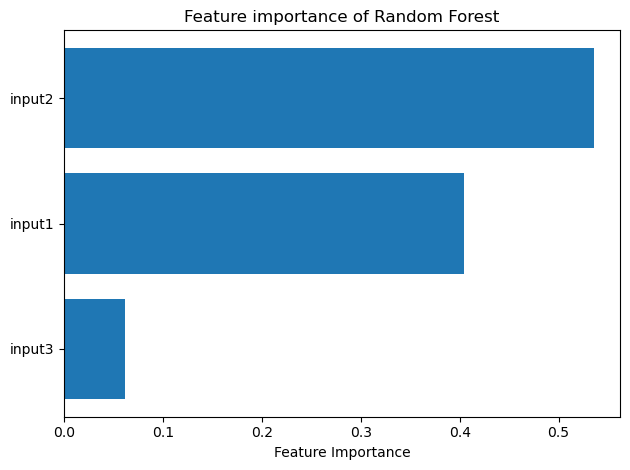

In [19]:
plt.barh(feature_importance_summary["input_variable"],feature_importance_summary["feature_importance"])
plt.title("Feature importance of Random Forest")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()